In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("dataset_penjualan.csv")

print("=== 5 Data Teratas ===")
print(df.head())

print("\n=== Info Dataset ===")
print(df.info())

print("\n=== Statistik Deskriptif ===")
print(df.describe())

print("\n=== Cek Missing Values ===")
print(df.isnull().sum())

=== 5 Data Teratas ===
  Order_ID            Product     Category   Price  Quantity  Order_Date  \
0   ORD001         Kaos Polos      Fashion   90000         1  2024-01-27   
1   ORD002     Sweater Hoodie      Fashion  150000         5  2024-03-19   
2   ORD003  Headset Bluetooth  Electronics  320000         1  2024-02-20   
3   ORD004       Mouse Gaming  Electronics  180000         2  2024-02-04   
4   ORD005       Mouse Gaming  Electronics  180000         3  2024-01-11   

       City  
0     Medan  
1  Surabaya  
2   Jakarta  
3   Bandung  
4  Surabaya  

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order_ID    100 non-null    object
 1   Product     100 non-null    object
 2   Category    100 non-null    object
 3   Price       100 non-null    int64 
 4   Quantity    100 non-null    int64 
 5   Order_Date  100 non-null  

In [3]:
# ============================================================
# 3. DATA PREPARATION
# ============================================================

# --- Convert tanggal ---
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# --- Feature Engineering ---
df["Revenue"] = df["Price"] * df["Quantity"]
df["Month"] = df["Order_Date"].dt.month
df["Year"] = df["Order_Date"].dt.year

print("\n=== Data Setelah Feature Engineering ===")
print(df.head())


=== Data Setelah Feature Engineering ===
  Order_ID            Product     Category   Price  Quantity Order_Date  \
0   ORD001         Kaos Polos      Fashion   90000         1 2024-01-27   
1   ORD002     Sweater Hoodie      Fashion  150000         5 2024-03-19   
2   ORD003  Headset Bluetooth  Electronics  320000         1 2024-02-20   
3   ORD004       Mouse Gaming  Electronics  180000         2 2024-02-04   
4   ORD005       Mouse Gaming  Electronics  180000         3 2024-01-11   

       City  Revenue  Month  Year  
0     Medan    90000      1  2024  
1  Surabaya   750000      3  2024  
2   Jakarta   320000      2  2024  
3   Bandung   360000      2  2024  
4  Surabaya   540000      1  2024  


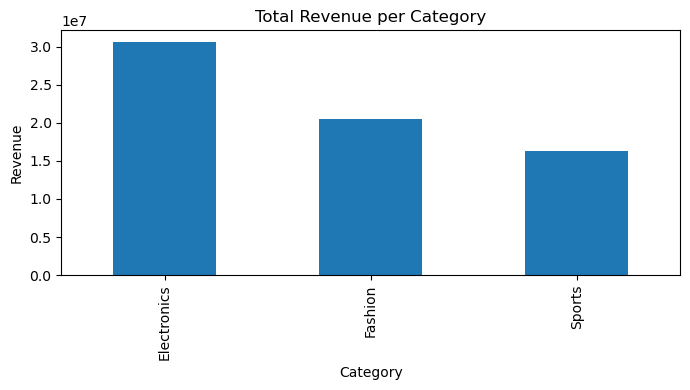

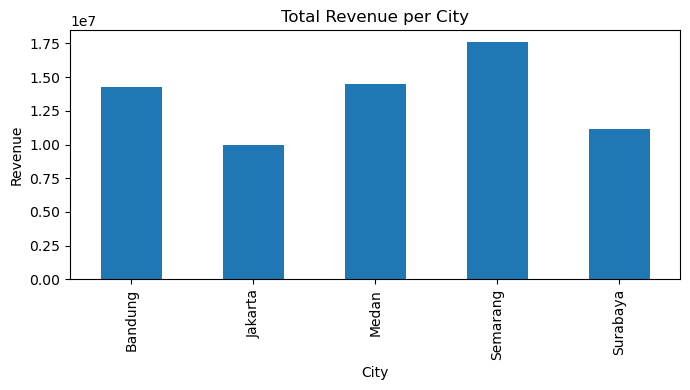

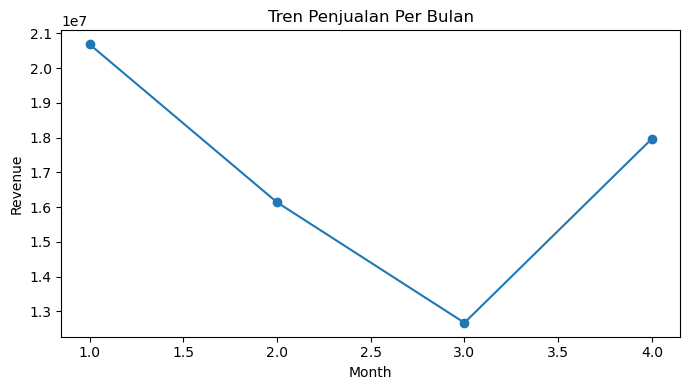

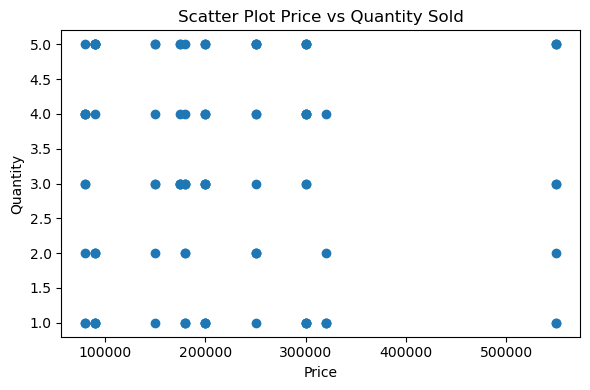

In [4]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Revenue per Category
plt.figure(figsize=(7,4))
df.groupby("Category")["Revenue"].sum().plot(kind="bar")
plt.title("Total Revenue per Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Revenue per City
plt.figure(figsize=(7,4))
df.groupby("City")["Revenue"].sum().plot(kind="bar")
plt.title("Total Revenue per City")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Monthly Sales Trend
plt.figure(figsize=(7,4))
df.groupby("Month")["Revenue"].sum().plot(kind="line", marker="o")
plt.title("Tren Penjualan Per Bulan")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Price vs Quantity
plt.figure(figsize=(6,4))
plt.scatter(df["Price"], df["Quantity"])
plt.title("Scatter Plot Price vs Quantity Sold")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()


In [4]:
# ============================================================
# 5. MODELING (Linear Regression)
# ============================================================

# --- Encoding: Category & City ---
df_model = pd.get_dummies(df, columns=["Category", "City"], drop_first=True)

# --- Features & Target ---
X = df_model[[
    "Price",
    "Quantity",
    "Month",
    "Year"
] + [col for col in df_model.columns if "Category_" in col or "City_" in col]]

y = df_model["Revenue"]

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- Train Model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- Predict ---
y_pred = model.predict(X_test)


In [5]:
# ============================================================
# 6. EVALUATION
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Evaluasi Model ===")
print("MAE :", mae)
print("MSE :", mse)
print("R²  :", r2)


=== Evaluasi Model ===
MAE : 146526.4497124643
MSE : 34312710771.63036
R²  : 0.7960599422782284


In [6]:
# ============================================================
# 7. FEATURE IMPORTANCE (COEFFICIENT)
# ============================================================

feature_coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\n=== Pengaruh Setiap Variabel (Coefficient) ===")
print(feature_coef)


=== Pengaruh Setiap Variabel (Coefficient) ===
            Feature   Coefficient
1          Quantity  2.362705e+05
9     City_Surabaya  4.572766e+04
5   Category_Sports  2.630559e+04
0             Price  3.166978e+00
3              Year  5.820766e-11
7        City_Medan -2.749850e+03
8     City_Semarang -4.244484e+03
2             Month -8.479797e+03
4  Category_Fashion -9.582466e+03
6      City_Jakarta -2.495492e+04
